# 04_01 · Evaluación de modelos baseline — AI4I

**Objetivo:** comparar todos los modelos baseline con las métricas adecuadas
para un problema de mantenimiento predictivo industrial.

### ¿Por qué no usamos Accuracy?
Con 3.4% de fallos, un modelo que prediga siempre "Normal" tiene 96.6% de accuracy.
Es una métrica engañosa para problemas desbalanceados.

### Métricas que usamos y por qué

| Métrica | Fórmula | Por qué importa aquí |
|---|---|---|
| **Recall** | TP / (TP + FN) | Proporción de fallos detectados — **métrica principal** |
| **Precision** | TP / (TP + FP) | Proporción de alarmas que son fallos reales |
| **F1** | 2·P·R / (P+R) | Balance Precision-Recall — útil para comparar modelos |
| **ROC-AUC** | Área bajo la curva ROC | Separabilidad global, independiente del umbral |

> **En mantenimiento industrial:** un Falso Negativo (fallo no detectado) puede costar
> 10x más que un Falso Positivo (alarma falsa). Por eso priorizamos Recall > Precision.


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              precision_recall_curve, f1_score,
                              precision_score, recall_score,
                              roc_auc_score)

with open('../../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../../models/models.pkl', 'rb') as f:
    models = pickle.load(f)

X_train, X_test, y_train, y_test = splits['ai4i']

PALETTE = {
    'Logistic Regression': 'royalblue',
    'Random Forest':       'seagreen',
    'XGBoost':             'darkorange',
    'LightGBM':            'crimson',
    'SVM':                 'mediumpurple',
}

all_models = [
    (models.get('lr'),   'Logistic Regression'),
    (models.get('rf'),   'Random Forest'),
    (models.get('xgb'),  'XGBoost'),
    (models.get('lgbm'), 'LightGBM'),
    (models.get('svm'),  'SVM'),
]
all_models = [(m, n) for m, n in all_models if m is not None]
print('Modelos cargados:', [n for _, n in all_models])


Modelos cargados: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'SVM']


## 1. Matrices de confusión

La matriz de confusión muestra exactamente qué tipo de errores comete cada modelo:

```
              Predicho
          Normal  Fallo
Real Normal  [TN]   [FP]   ← FP = alarma falsa (coste bajo)
     Fallo   [FN]   [TP]   ← FN = fallo no detectado (coste alto)
```

**En este problema buscamos:** FN bajo (pocos fallos escapados) aunque FP sea algo mayor.


/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


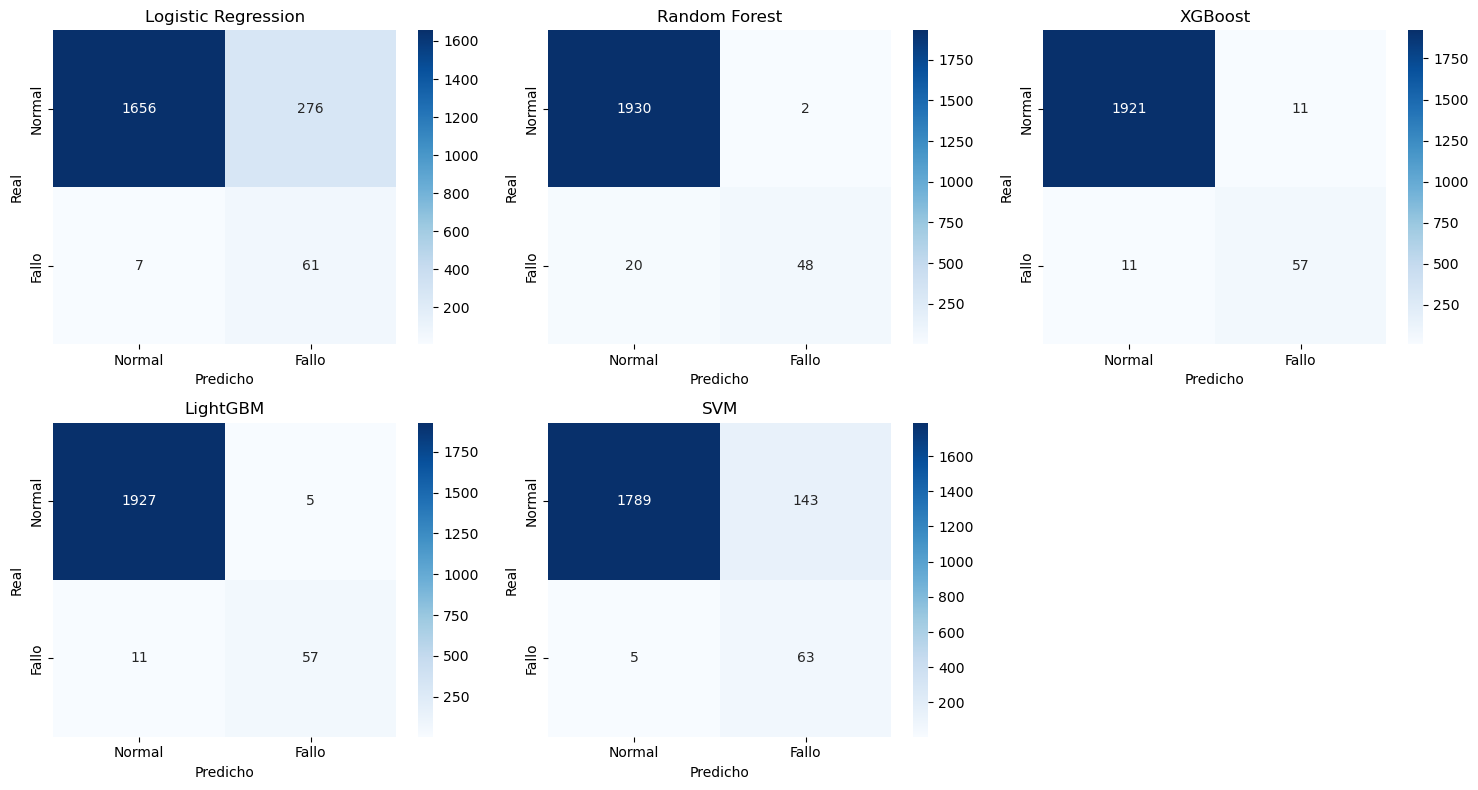

In [2]:
n = len(all_models)
ncols = min(n, 3)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for ax, (model, name) in zip(axes, all_models):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fallo'], yticklabels=['Normal', 'Fallo'])
    ax.set_title(name)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 2. Curvas ROC

La curva ROC muestra el trade-off entre TPR (Recall) y FPR para todos los umbrales posibles.

- **AUC = 1.0**: modelo perfecto
- **AUC = 0.5**: modelo aleatorio (línea diagonal)
- **AUC > 0.97**: excelente separabilidad, típico para este dataset sintético

> **Nota:** el ROC puede ser optimista en problemas muy desbalanceados.
> La curva Precision-Recall (siguiente sección) es más informativa aquí.


/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


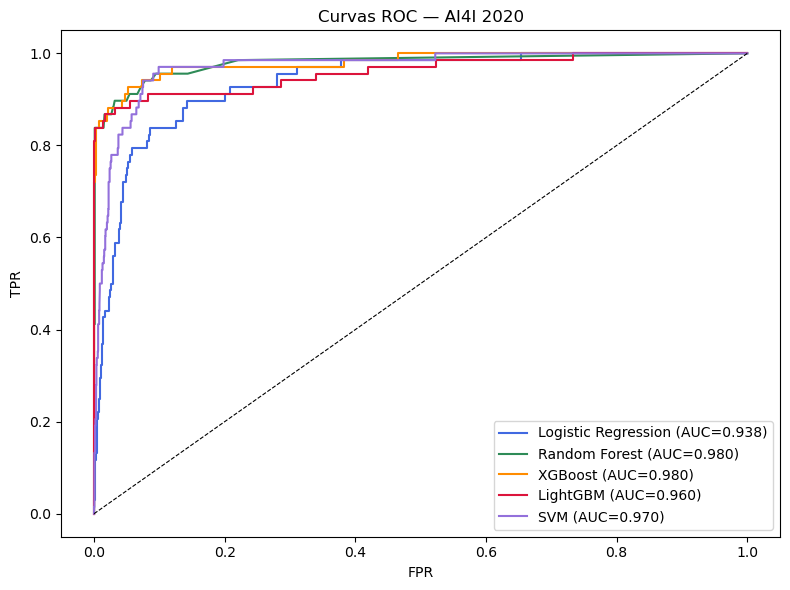

In [3]:
plt.figure(figsize=(8, 6))
for model, name in all_models:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, color=PALETTE[name],
             label=f'{name} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curvas ROC — AI4I 2020')
plt.legend()
plt.tight_layout()
plt.show()


## 3. Curva Precision-Recall

La curva PR es más informativa que el ROC para problemas desbalanceados:
muestra el trade-off entre Precision y Recall a medida que variamos el umbral.

- **Arriba a la derecha** = mejor modelo (alta Precision Y alto Recall)
- El **área bajo la curva PR** (AP) es equivalente al ROC-AUC pero centrado en la clase minoritaria
- Una línea horizontal en Precision = 0.034 corresponde a un clasificador aleatorio (solo acierta por la tasa base)

> En este gráfico vemos visualmente dónde está el **umbral óptimo** para Recall ≥ 0.85.


/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


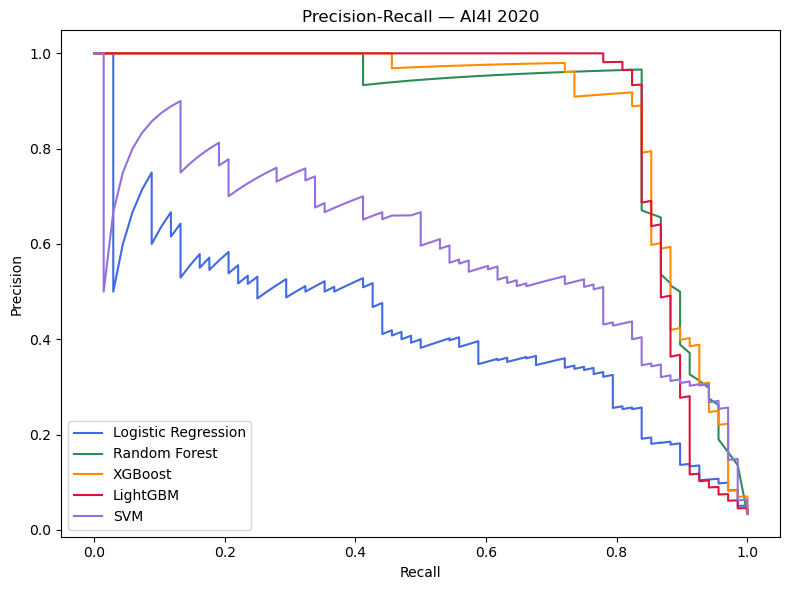

In [4]:
plt.figure(figsize=(8, 6))
for model, name in all_models:
    prec, rec, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(rec, prec, color=PALETTE[name], label=name)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall — AI4I 2020')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Tabla de métricas comparativa

Todos los modelos evaluados con el umbral por defecto (0.5).

> **Atención:** el umbral 0.5 no es el óptimo para datos desbalanceados.
> En notebooks posteriores ajustaremos el umbral para cada modelo buscando
> el máximo F1 con Recall ≥ 0.85. Esta tabla es solo el punto de partida.


In [5]:
results = []
for model, name in all_models:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Modelo': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    })

df_res = pd.DataFrame(results).set_index('Modelo').round(4)
df_res.sort_values('ROC-AUC', ascending=False)


/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nora/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Precision,Recall,F1,ROC-AUC
Modelo,,,,
XGBoost,0.8382,0.8382,0.8382,0.9800
Random Forest,0.9600,0.7059,0.8136,0.9797
SVM,0.3058,0.9265,0.4599,0.9702
LightGBM,0.9194,0.8382,0.8769,0.9596
Logistic Regression,0.1810,0.8971,0.3012,0.9378


## 5. Conclusiones — próximos pasos

Los modelos baseline muestran un rango amplio de F1 (0.30 a 0.88).
Los modelos de boosting (XGBoost, LightGBM) son los más prometedores.

**Qué haremos en los siguientes notebooks (carpeta `05_MODELOS_AFINADOS`):**
- **05_01_1_LightGBM**: afinar LightGBM (Optuna + ajuste de umbral)
- **05_01_2_RF**: afinar Random Forest
- **05_01_3_SVM**: afinar SVM
- **05_01_4_Stacking**: construir y comparar los ensembles (v1/v2/v3) → **modelo de producción**

La evaluación del modelo final (impacto de negocio, análisis de falsos negativos,
tradeoff de umbral y SHAP) está en **`06_MODELOS_FINALES/06_04_Evaluacion_Final`**,
que se ejecuta después de la cadena 05.
